CONTENTS:
- [Exploratory Data Analysis: Gridstatus metadata](#exploratory-data-analysis:-gridstatus-metadata)
    - [Initial Observations](#initial-observations)
    - [Missing Value Summary](#missing-value-summary)

<a name='exploratory-data-analysis:-gridstatus-metadata'></a>
# Exploratory Data Analysis: Gridstatus metadata

This notebook analyzes the metadata of 268 time series datasets available on [GridStatus.io](https://www.gridstatus.io/datasets). The metadata is loaded from the AWS S3 bucket `causify-data-collaborators` using helper functions from `./helpers_root/helpers/hs3.py`. The goal is to explore the variety, coverage, and quality of the available time series data.

In [5]:
# Import necessary libraries and modules.
import io

import helpers.hs3 as hs3
import IPython.display as disp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
# Read metadata from the S3 bucket.
file_path = "s3://causify-data-collaborators/causal_automl/metadata/gridstatus_metadata.csv"
file = hs3.from_file(file_path, aws_profile="ck")
gs_meta = pd.read_csv(io.StringIO(file))

In [7]:
print(gs_meta.shape)
print(gs_meta.columns)
disp.display(gs_meta.head())

(268, 19)
Index(['id', 'name', 'description', 'earliest_available_time_utc',
       'latest_available_time_utc', 'source', 'last_checked_time_utc',
       'primary_key_columns', 'publish_time_column', 'time_index_column',
       'subseries_index_column', 'all_columns', 'number_of_rows_approximate',
       'table_type', 'is_in_snowflake', 'data_frequency', 'source_url',
       'publication_frequency', 'is_published'],
      dtype='object')


,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,subseries_index_column,all_columns,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published
0,all_records,All Records,Top daily records for various metrics across a...,2017-12-13T22:05:00+00:00,2025-03-26T15:30:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'rank', 'record_type', 'metric_name']",NaN,interval_start_utc,NaN,"[{'name': 'rank', 'type': 'BIGINT', 'is_numeri...",620,materialized_view,False,IRREGULAR,NaN,NaN,True
1,all_records_timeseries,All Records Timeseries,Timeline of new records for various metrics in...,2011-01-01T06:30:00+00:00,2025-03-25T00:40:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'interval_start_utc', 'record_type', '...",NaN,interval_start_utc,NaN,"[{'name': 'iso', 'type': 'TEXT', 'is_numeric':...",2076,materialized_view,False,IRREGULAR,NaN,NaN,True
2,caiso_as_prices,CAISO AS Prices,Ancillary Services Prices as reported by CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:12+00:00,"['interval_start_utc', 'region', 'market']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",621445,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True
3,caiso_as_procurement_dam,CAISO AS Procurement DAM,Ancillary services procurement data from CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:17+00:00,"['interval_start_utc', 'region']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",623449,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True
4,caiso_curtailed_non_operational_generator_report,CAISO Curtailed Non Operational Generator Report,Prior Day Curtailed Non-Operational Generator ...,2021-06-18T07:00:00+00:00,2025-04-09T07:00:00+00:00,caiso,2025-04-09T15:37:31+00:00,"['publish_time_utc', 'outage_mrid', 'curtailme...",publish_time_utc,curtailment_start_time_utc,NaN,"[{'name': 'publish_time_utc', 'type': 'TIMESTA...",2490715,table,True,IRREGULAR,https://www.caiso.com/market-operations/outage...,NaN,True


<a name='initial-observations'></a>
### Initial Observations

From the 19 columns available in the GridStatus metadata, the following are most relevant for initial exploratory analysis:

- `source` : Identifies the origin of each dataset.
- `data_frequency` : Describes the granularity of data (e.g. 5 minutes, 1 hour, 1 day, etc).
- `is_in_snowflake` : Indicates whether the dataset is already ingested into the internal Snowflake warehouse.
- `table_type` : Helps categorize datasets by their structure or intended purpose (table, view, materialized view).
- `earliest_available_time_utc` : Indicates the starting point of data availability for each dataset.
- `latest_available_time_utc` : Indicates the most recent timestamp available in each dataset.


Several other metadata fields are available but were excluded from the initial analysis for the following reasons:

- Columns like `id`, `name`, and `description` are identifiers or unstructured text, making them unsuitable for analysis.
- Fields like `primary_key_columns`, `publish_time_column`, `subseries_index_column`, and `all_columns` are helpful for database structure but not very useful for analyzing overall metadata patterns.
- Fields like `last_checked_time_utc` are useful for monitoring and tracking system activity.
- `source_url` is a similar to `source`, as it includes a direct link to the data source, but it contains some null values and may not always be available.
- `number_of_rows_approximate` can be leveraged in future analytical processes to perform dataset size comparisons, enabling scalability assessments and optimization strategies.
- `time_index_column` indicates the name of the column containing timestamps, making it useful for dataset structure but not for actual time-based analysis.
- `is_published` is consistently `True` for all records (unless the metadata is updated) and therefore not relevant for analysis.
- `publication_frequency` is null for all records except one, and as a result, it is excluded from the analysis.

**1. Source Distribution**

Most of the datasets come from ERCOT, PJM, and CAISO, which are among the most active grid operators. Together, they make up over half of all datasets, showing a strong focus on these sources, possibly due to better data availability, higher reliability, or their overall importance in grid operations.

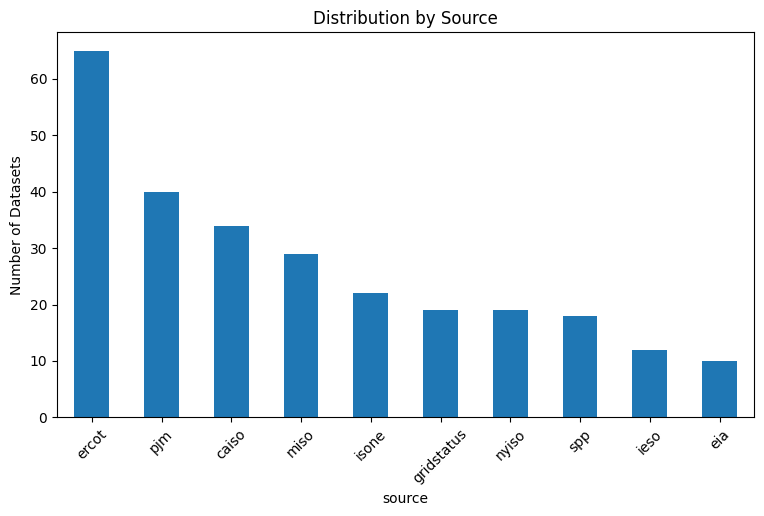

In [8]:
# Plot the distribution of entries by source from the dataframe.
plt.figure(figsize=(9, 5))
gs_meta["source"].value_counts().plot(kind="bar")
plt.title("Distribution by Source")
plt.ylabel("Number of Datasets")
plt.xticks(rotation=45)
plt.show()

**2. Frequency Distribution**

Most of the datasets in GridStatus are updated frequently, with the majority being hourly or every 5 minutes. This suggests that the system is focused on providing up-to-date, real-time data, while fewer datasets cater to more specialized or less frequent data needs.

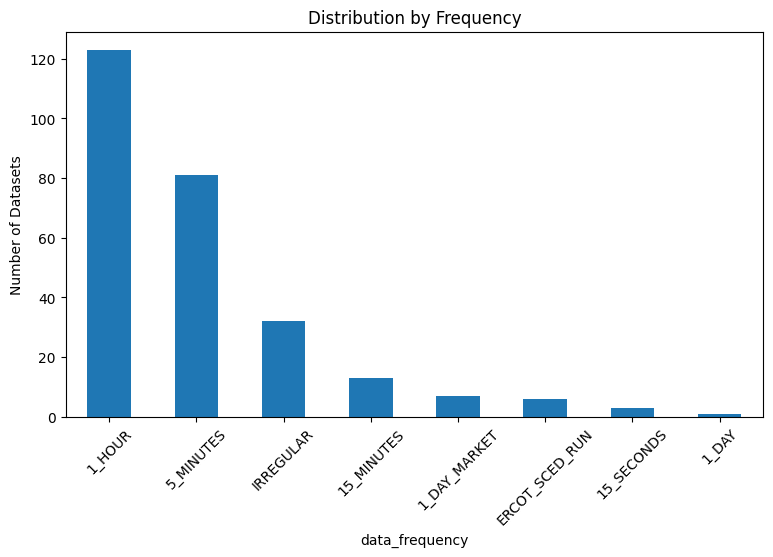

In [9]:
# Plot the distribution of entries by frequency from the dataframe.
plt.figure(figsize=(9, 5))
gs_meta["data_frequency"].dropna().value_counts().plot(kind="bar")
plt.title("Distribution by Frequency")
plt.ylabel("Number of Datasets")
plt.xticks(rotation=45)
plt.show()

**3. How far the data goes back**

The earliest available datasets show that a few have data starting from 1993 and 2000-2002, which suggests there is some long-term historical data. However, most datasets have data starting from around 2010 and later, with a noticeable drop in 2020. This dip might mean fewer datasets were available or that data collection changed during that time. Overall, most of the data is from the last 10 years, with some older data available before 2010.

In [10]:
# Convert timestamps to DateTime format.
gs_meta["earliest_available_time_utc"] = pd.to_datetime(
    gs_meta["earliest_available_time_utc"]
)
gs_meta["latest_available_time_utc"] = pd.to_datetime(
    gs_meta["latest_available_time_utc"]
)

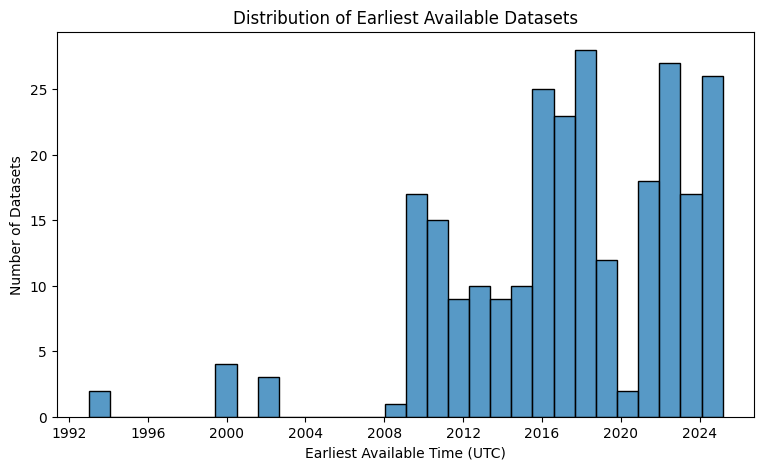

In [11]:
# Plot a histogram of the earliest available datasets.
plt.figure(figsize=(9, 5))
sns.histplot(gs_meta["earliest_available_time_utc"].dropna(), bins=30, kde=False)
plt.title("Distribution of Earliest Available Datasets")
plt.xlabel("Earliest Available Time (UTC)")
plt.ylabel("Number of Datasets")
plt.show()

In [12]:
# Display the dataset(s) with the earliest available time.
earliest_rows = gs_meta[
    gs_meta["earliest_available_time_utc"]
    == gs_meta["earliest_available_time_utc"].min()
]
print("Earliest available dataset(s):")
disp.display(earliest_rows)

Earliest available dataset(s):


,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,subseries_index_column,all_columns,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published
222,pjm_load_metered_hourly,PJM Load Metered Hourly,The MWh net energy consumption by each service...,1993-01-01 05:00:00+00:00,2025-04-08 03:00:00+00:00,pjm,2025-04-09T15:38:01+00:00,"['interval_start_utc', 'mkt_region', 'zone', '...",NaN,interval_start_utc,load_area,"[{'name': 'interval_start_utc', 'type': 'TIMES...",5681485,table,True,1_HOUR,https://dataminer2.pjm.com/feed/hrl_load_meter...,NaN,True


**4. Dataset Coverage Distribution**

The distribution of dataset coverage follows a clear multimodal pattern, with the Kernel Density Estimate (KDE) curve showing a concentration of datasets around 3,000 days, indicating that most datasets provide medium-term historical coverage. There is also a significant concentration around 1,000 days, reflecting a large number of more recent datasets. The curve shows a noticeable gap after 6,000 days, suggesting fewer datasets with coverage beyond this point. This pattern highlights the availability of datasets across various time spans, from recent data to long-term historical records, while pointing to a potential gap in coverage for datasets lasting beyond 6,000 days.

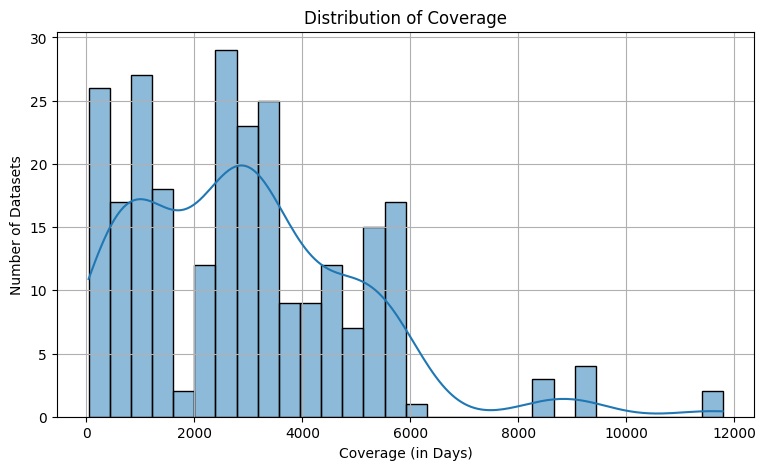

In [13]:
# Plot the distribution of dataset coverage with a Kernel Density Estimate (KDE) overlay.
gs_meta["coverage"] = (
    gs_meta["latest_available_time_utc"] - gs_meta["earliest_available_time_utc"]
).dt.days
plt.figure(figsize=(9, 5))
sns.histplot(gs_meta["coverage"], bins=30, kde=True)
plt.title("Distribution of Coverage")
plt.xlabel("Coverage (in Days)")
plt.ylabel("Number of Datasets")
plt.grid(True)
plt.show()

**5. Coverage per Top 10 Source**

This plot shows the distribution of dataset coverage durations, measured in days, for the ten most common data sources in the GridStatus metadata. Each boxplot captures the range and spread of coverage values within a source, while the overlaid stripplot reveals individual datasets and highlights variability or clustering. This visualization offers a comparative view of how long data has been collected across different sources and how consistent that coverage is within each group. By examining the shape, spread, and outliers for each source, we can draw our own conclusions about the historical depth, completeness, or variability of the data available from each provider.

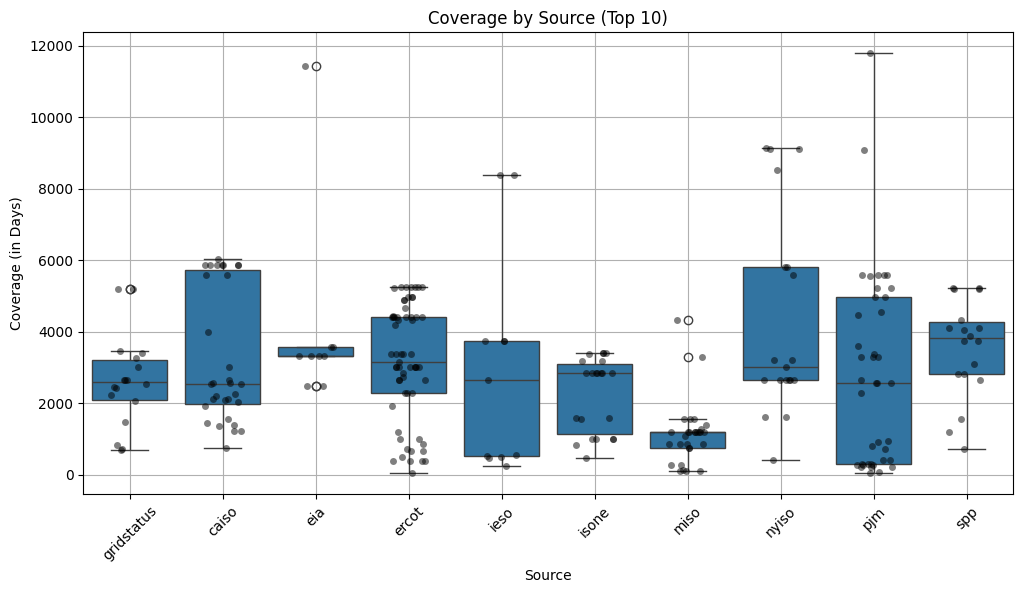

In [14]:
# Plot coverage distribution by top 10 sources using box and strip plots.
plt.figure(figsize=(12, 6))
top_sources = gs_meta["source"].value_counts().nlargest(10).index
source_top_10 = gs_meta[gs_meta["source"].isin(top_sources)]
sns.boxplot(data=source_top_10, x="source", y="coverage")
sns.stripplot(
    data=source_top_10,
    x="source",
    y="coverage",
    color="black",
    alpha=0.5,
    jitter=0.2,
)
plt.title("Coverage by Source (Top 10)")
plt.xlabel("Source")
plt.ylabel("Coverage (in Days)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**6. Coverage Insights by Frequency and Snowflake Ingestion**

The distribution of coverage durations across data frequencies reveals that the majority of datasets fall under the ‘1 hour’ and ‘5 mins’ categories (as shown in the previous graphs), reflecting a clear emphasis on high-resolution time series data. Notably, most of these high-frequency datasets are already ingested into Snowflake, suggesting that ingestion efforts are prioritized for data streams that support real-time or near-real-time analytics.

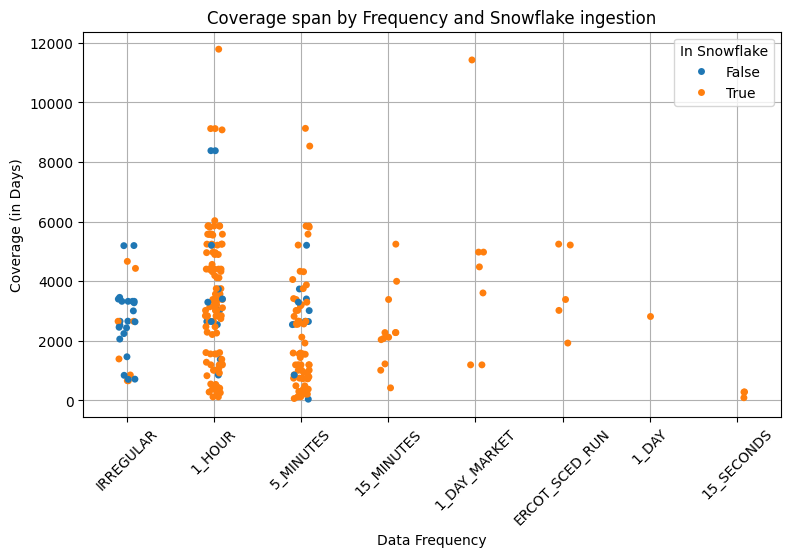

In [15]:
# Plot coverage span by data frequency, colored by Snowflake status.
plt.figure(figsize=(9, 5))
sns.stripplot(
    data=gs_meta,
    x="data_frequency",
    y="coverage",
    hue="is_in_snowflake",
    jitter=True,
)
plt.title("Coverage span by Frequency and Snowflake ingestion")
plt.xlabel("Data Frequency")
plt.ylabel("Coverage (in Days)")
plt.grid(True)
plt.legend(title="In Snowflake")
plt.xticks(rotation=45)
plt.show()

**7. Snowflake Ingestion Insights by Table Type**

The analysis of Snowflake ingestion shows some interesting patterns across different data types. All `materialized_view` entries are not ingested into Snowflake, which could mean they are either not needed in Snowflake or they are used in a different way. This might point to a gap in the data pipeline, where `materialized_view` datasets are not being properly integrated. On the other hand, around 95% of `table_view` entries are successfully ingested into Snowflake, showing that most structured data is already in the system. Around 90% of `view` entries are not ingested into Snowflake, which might mean that they are considered less important or are not yet ready for integration. It may be worth reviewing if some views should be added to Snowflake, especially if they are needed for analysis. Overall, while Snowflake is doing well with `table_view`, there’s room for improvement with `materialized_view` and `view`.

**Note:** The following plot may be misleading if observed without context, as it could lead to incorrect conclusions. Since all `materialized_view` and most `view` entries are not ingested into Snowflake, one might mistakenly assume that the entries across this metadata are not ingested by Snowflake. In reality, around 85% of the entries fall under the `table_view`, and 95% of all `table_view` entries are ingested by Snowflake. Therefore, the majority of the data is successfully ingested into Snowflake, and this context is important for drawing accurate conclusions.

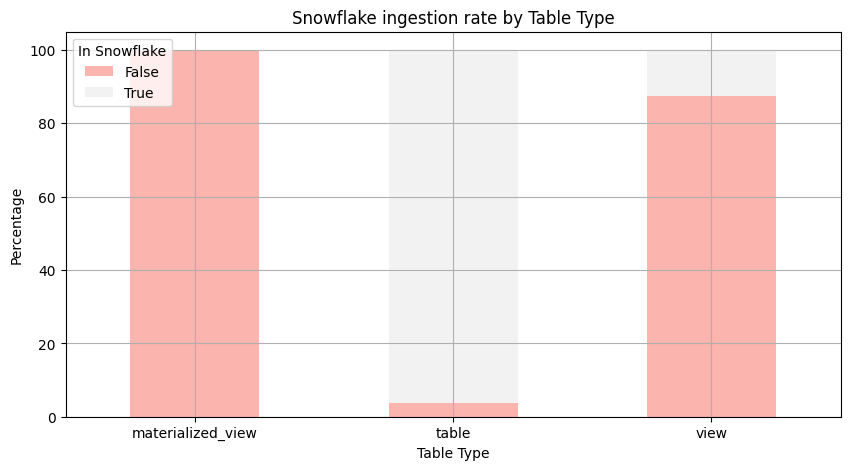

In [16]:
# Plot a normalized stacked bar chart of Snowflake ingestion by table type using a colormap.
sf_by_ttype = (
    pd.crosstab(
        gs_meta["table_type"], gs_meta["is_in_snowflake"], normalize="index"
    )
    * 100
)
sf_by_ttype.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Pastel1")
plt.title("Snowflake ingestion rate by Table Type")
plt.ylabel("Percentage")
plt.xlabel("Table Type")
plt.legend(title="In Snowflake")
plt.xticks(rotation=0, ha="center")
plt.grid(True)
plt.show()

<a name='missing-value-summary'></a>
### Missing Value Summary

The table below shows the number of missing (null) values in each metadata field, helping identify potential data quality issues.


In [17]:
# Display missing metadata statistics.
missing_count = gs_meta.isna().sum().sort_values(ascending=False)
missing_percent = (
    (gs_meta.isna().mean() * 100).sort_values(ascending=False).round(2)
)
missing_gs_meta = pd.DataFrame(
    {"Missing Count": missing_count, "Missing %": missing_percent}
)
missing_gs_meta = missing_gs_meta[missing_gs_meta["Missing Count"] > 0]
disp.display(missing_gs_meta)

,Missing Count,Missing %
publication_frequency,267,99.63
publish_time_column,198,73.88
subseries_index_column,161,60.07
source_url,37,13.81
coverage,10,3.73
latest_available_time_utc,10,3.73
earliest_available_time_utc,10,3.73
last_checked_time_utc,9,3.36
time_index_column,8,2.99
table_type,4,1.49


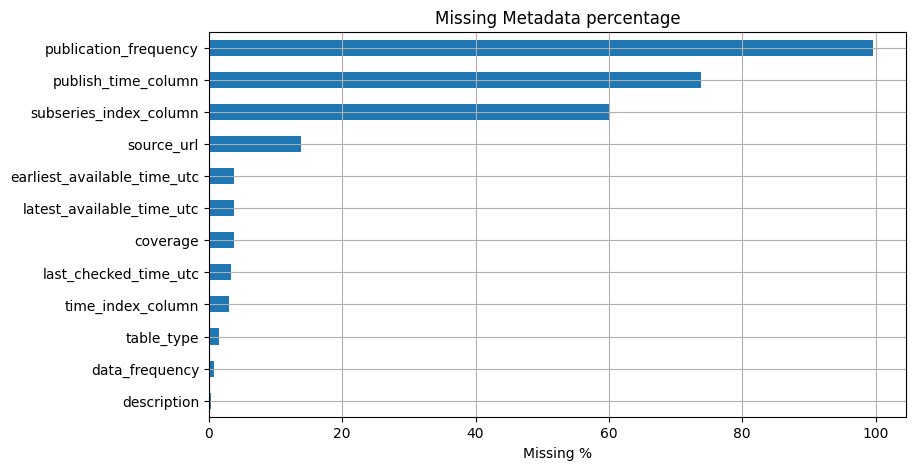

In [18]:
# Plot missing metadata statistics.
missing_gs_meta[missing_gs_meta["Missing Count"] > 0].sort_values(
    "Missing %", ascending=True
)["Missing %"].plot(
    kind="barh", figsize=(9, 5), title="Missing Metadata percentage"
)
plt.xlabel("Missing %")
plt.grid(True)
plt.show()